# 02 – Data Preparation
Label unification, deduplication, and stratified splitting.


In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Run full data preparation pipeline
*(or load already-processed files if they exist)*

In [7]:
from pathlib import Path
from src.utils.io import load_jsonl

processed = Path('../data/processed')

if not (processed / 'train.jsonl').exists():
    print('Running prepare_data.py …')
    import subprocess
    subprocess.run(['python', '../prepare_data.py'], check=True)

train = load_jsonl(processed / 'train.jsonl')
val   = load_jsonl(processed / 'val.jsonl')
test  = load_jsonl(processed / 'test.jsonl')
print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')

train=37,661  val=4,707  test=4,710


## 2. Unified label distribution

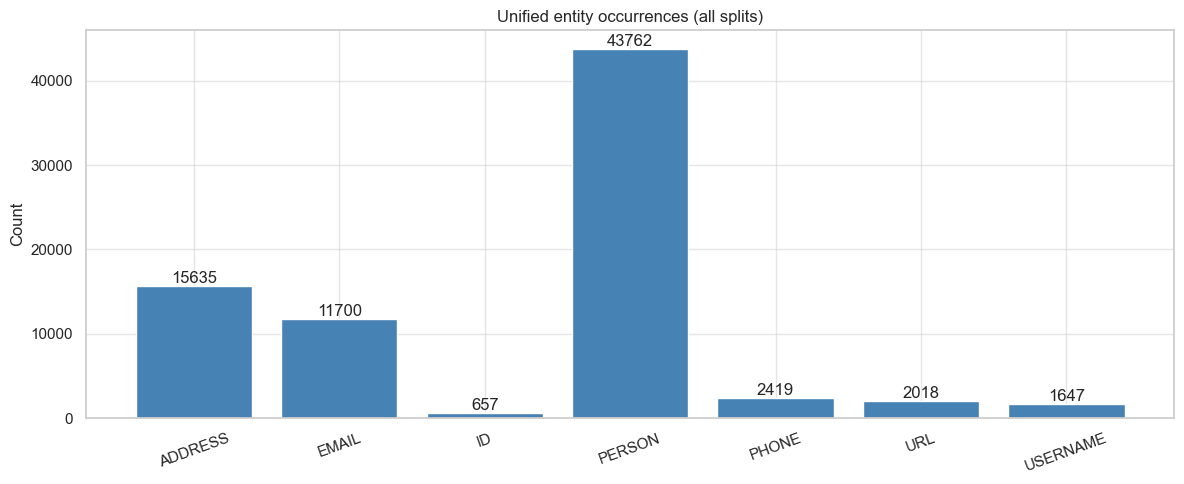

In [8]:
cnt = Counter()
for rec in train + val + test:
    for lbl in rec['labels']:
        if lbl.startswith('B-'):
            cnt[lbl[2:]] += 1

entities = sorted(cnt.keys())
values   = [cnt[e] for e in entities]

fig, ax = plt.subplots()
bars = ax.bar(entities, values, color='steelblue', edgecolor='white')
ax.bar_label(bars)
ax.set_title('Unified entity occurrences (all splits)')
ax.set_ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/unified_label_dist.png', dpi=150)
plt.show()

## 3. Split statistics

In [9]:
import pandas as pd

def split_stats(records, name):
    n_pii = sum(1 for r in records if any(l != 'O' for l in r['labels']))
    kaggle = sum(1 for r in records if r.get('source') == 'kaggle')
    ai4p   = sum(1 for r in records if r.get('source') == 'ai4privacy')
    return {'split': name, 'total': len(records), 'has_pii': n_pii,
            'pii_%': f'{n_pii/len(records)*100:.1f}', 'kaggle': kaggle, 'ai4privacy': ai4p}

stats = pd.DataFrame([split_stats(train,'train'), split_stats(val,'val'), split_stats(test,'test')])
stats.set_index('split', inplace=True)
print(stats.to_string())

       total  has_pii pii_%  kaggle  ai4privacy
split                                          
train  37661    34841  92.5    3584       34077
val     4707     4355  92.5     441        4266
test    4710     4356  92.5     409        4301


## 4. Sample unified records

In [10]:
import random
rng = random.Random(42)
pii_samples = [r for r in test if any(l != 'O' for l in r['labels'])]

for rec in rng.sample(pii_samples, 3):
    toks, lbls = rec['tokens'], rec['labels']
    pii = [(t, l) for t, l in zip(toks, lbls) if l != 'O']
    src = rec.get('source', '?')
    print(f'[{src}]  ...{" ".join(toks[:15])}...')
    print(f'  PII: {pii[:6]}')
    print()

[ai4privacy]  ...can you help me create a list of coping strategies for simonis - mueller to...
  PII: [('simonis', 'B-PERSON'), ('-', 'I-PERSON'), ('mueller', 'I-PERSON')]

[kaggle]  ...In the realm of design, Ashok Novikov stands as a beacon of creativity and innovation....
  PII: [('Ashok', 'B-PERSON'), ('Novikov', 'I-PERSON'), ('Ashok', 'B-PERSON'), ("Ashok's", 'B-PERSON'), ('Ashok', 'B-PERSON'), ('Ashok', 'B-PERSON')]

[ai4privacy]  ...draft a pitch deck for crona inc to present their startup idea to potential investors...
  PII: [('crona', 'B-PERSON'), ('inc', 'I-PERSON')]

